# Project
Implement a Recommender System integrated with an LLM by installing necessary libraries, defining `RecDataset` and `RecDataCollator`, creating `PromptTemplate` and `PromptBuilder` for text/ID prompts, developing `RecEncoderBase` with `MFEncoder`, implementing `CollaborativeToLLMProjection`, building the `LLMBackbone`, and integrating these components to run a dummy forward pass.

# **0. Setup Environment:**

## Clone repository


### Clone Repository
To clone a private repo, you need a **Personal Access Token (PAT)**.
1. Go to [GitHub Tokens](https://github.com/settings/tokens).
2. Generate a new token (Classic) with **repo** scope.
3. Run the cell below and enter your credentials.

In [ ]:
import os
from getpass import getpass

token = getpass("Enter your GitHub Personal Access Token (PAT): ")

repo_name = "SigLLM"
repo_url = f"https://{token}@github.com/QuocBaoBuiNguyen/{repo_name}.git"

!git clone {repo_url}
%cd SigLLM
!git checkout develop
!ls -a

Enter your GitHub Personal Access Token (PAT): ··········
Cloning into 'SigLLM'...
remote: Enumerating objects: 280, done.
remote: Counting objects: 100% (271/271), done.
remote: Compressing objects: 100% (137/137), done.
remote: Total 280 (delta 101), reused 249 (delta 81), pack-reused 9 (from 2)
Receiving objects: 100% (280/280), 84.59 MiB | 28.38 MiB/s, done.
Resolving deltas: 100% (101/101), done.
/content/SigLLM
Already on 'develop'
Your branch is up to date with 'origin/develop'.
.  ..  configs	data  env.yaml	.git  .gitignore  requirements.txt  src


In [41]:
!git pull origin develop

remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 3), reused 5 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 1.25 KiB | 1.25 MiB/s, done.
From https://github.com/QuocBaoBuiNguyen/SigLLM
 * branch            develop    -> FETCH_HEAD
   5127efa..fb776b2  develop    -> origin/develop
Updating 5127efa..fb776b2
Fast-forward
 env.yaml | 79 ++++++++++++++++++++++++++++++++++++++++++++--------------------
 1 file changed, 55 insertions(+), 24 deletions(-)


### Reload (Must run after pulling new code)

In [42]:
import sys
import importlib
from types import ModuleType

imp = ModuleType('imp')
imp.reload = importlib.reload
sys.modules['imp'] = imp

# %load_ext autoreload
# %autoreload 2
%reload_ext autoreload

In [27]:
%env PYTHONPATH=src:$PYTHONPATH

env: PYTHONPATH=src:$PYTHONPATH


**Reasoning**:
Import torch and check for CUDA availability to verify that the GPU is accessible.



In [ ]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")

CUDA available: True


## Setup conda


In [ ]:
!wget -c https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O /content/Miniconda3.sh
!chmod +x /content/Miniconda3.sh
!bash /content/Miniconda3.sh -b -f -p /usr/local

--2026-02-20 01:36:39--  https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.191.158, 104.16.32.241, 2606:4700::6810:20f1, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.191.158|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 156772981 (150M) [application/octet-stream]
Saving to: ‘/content/Miniconda3.sh’

/content/Miniconda3 100%[===================>] 149.51M   190MB/s    in 0.8s    

2026-02-20 01:36:40 (190 MB/s) - ‘/content/Miniconda3.sh’ saved [156772981/156772981]

PREFIX=/usr/local
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTH

In [ ]:
import sys
sys.path.append('/usr/local/lib/python3.12/site-packages')

In [ ]:
!conda --version

conda 25.11.1


In [ ]:
!source /usr/local/etc/profile.d/conda.sh && conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!source /usr/local/etc/profile.d/conda.sh && conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r


In [ ]:
!source /usr/local/etc/profile.d/conda.sh && conda env create -f /content/SigLLM/env.yaml

Streaming output truncated to the last 5000 lines.
pytorch-2.5.1        | 1.35 GB   | :   2% 0.02135744360622602/1 [00:01<00:58, 59.45s/it]



libcusparse-12.0.2.5 | 163.0 MB  | :  36% 0.3607140086511517/1 [00:01<00:02,  4.12s/it]
libcublas-12.1.0.26  | 329.0 MB  | :  18% 0.18471436469365474/1 [00:01<00:06,  8.23s/it]


mkl-2023.1.0         | 171.5 MB  | :  35% 0.3488647315791055/1 [00:01<00:03,  4.62s/it]

pytorch-2.5.1        | 1.35 GB   | :   2% 0.02314849504788738/1 [00:01<00:57, 58.69s/it]



libcusparse-12.0.2.5 | 163.0 MB  | :  39% 0.38535608739207305/1 [00:01<00:02,  4.22s/it]
libcublas-12.1.0.26  | 329.0 MB  | :  20% 0.19696849328479973/1 [00:01<00:06,  8.50s/it]


mkl-2023.1.0         | 171.5 MB  | :  38% 0.3787413978866634/1 [00:01<00:02,  4.18s/it]

torchtriton-3.1.0    | 233.6 MB  | :  29% 0.2914714203896947/1 [00:01<00:04,  5.79s/it]



libcusparse-12.0.2.5 | 163.0 MB  | :  42% 0.417381201397784/1 [00:01<00:02,  3.85s/it]  
pytorch-2.5.1        | 1.35 GB   | :   2% 0.0249

In [18]:
!source /usr/local/etc/profile.d/conda.sh && conda env list


# conda environments:
#
# * -> active
# + -> frozen
base                     /usr/local
sigllm                   /usr/local/envs/sigllm



In [19]:
!source /usr/local/etc/profile.d/conda.sh && conda activate sigllm

### Run this only in case update env.yaml

In [43]:
# !source /usr/local/etc/profile.d/conda.sh && conda env update --file env.yaml --prune

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - pytorch
 - conda-forge
 - defaults
 - anaconda
Platform: linux-64
Solving environment: / - \ done


==> WARNING: A newer version of conda exists. <==
    current version: 25.11.1
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda



pytorch-1.12.1       | 1.20 GB   | :   0% 0/1 [00:00<?, ?it/s]
cudatoolkit-11.6.2   | 598.8 MB  | :   0% 0/1 [00:00<?, ?it/s]

pillow-9.4.0         | 44.1 MB   | :   0% 0/1 [00:00<?, ?it/s]


icu-72.1             | 11.4 MB   | :   0% 0/1 [00:00<?, ?it/s]



ffmpeg-6.0.0         | 9.4 MB    | :   0% 0/1 [00:00<?, ?it/s]




torchvision-0.13.1   | 7.5 MB    | :   0% 0/1 [00:00<?, ?it/s]





matplotlib-base-3.9. | 6.7 MB    | :   0% 0/1 [00:00<?, ?it/s]






torchaudio-0.12.1    | 6.1 MB    | :   0% 0/1 [00:00<?, ?it/s]







libglib-2.86.0       | 3.8 MB    | :   0% 0/1 [00:00<?, ?it/s]








tk-8.6.13            | 3.1 MB    | 

# **1. Dataset Preparation:**

## Download and prepare datasets

In [22]:
import sys
sys.path.insert(0, "src")

In [52]:
!rm -rf /content/SigLLM/data/processed/

In [23]:
!unzip /content/SigLLM/data/raw/ml-1m.zip -d /content/SigLLM/data/raw/

Archive:  /content/SigLLM/data/raw/ml-1m.zip
   creating: /content/SigLLM/data/raw/ml-1m/
  inflating: /content/SigLLM/data/raw/ml-1m/movies.dat  
  inflating: /content/SigLLM/data/raw/ml-1m/ratings.dat  
  inflating: /content/SigLLM/data/raw/ml-1m/README  
  inflating: /content/SigLLM/data/raw/ml-1m/users.dat  


## Primary ML-1M preprocessing: handles temporal splitting, ID remapping, and sequential history construction.


In [53]:
!source /usr/local/etc/profile.d/conda.sh && conda activate sigllm && \
python /content/SigLLM/src/sigllm/datasets/data_preprocessing.py

02:44:04 | [1/10] Load raw tables | ratings + movies + users
02:44:10 | Raw shapes | ratings=(1000209, 4), movies=(3883, 3), users=(6040, 5)
02:44:10 | [2/10] Merge metadata | content-aware enrichment (title/genres)
02:44:10 | Merged table | shape=(1000209, 6)
02:44:10 | [3/10] Inspect time span | temporal coverage
02:44:11 | Time extrema | 2000-04-25 -> 2003-02-28
02:44:11 | Total months | 34
02:44:11 | [4/10] Build time slots | prevent leakage via temporal split
02:44:12 | Time bins | count=35, range=(0, 34)
02:44:12 | Plot time histogram | volume vs slot for drift check
02:44:12 | [5/10] Define temporal windows | train=[14, 15, 16, 17, 18, 19, 20, 21, 22, 23], valid=[24, 25, 26, 27, 28], test=[29, 30, 31, 32, 33]
02:44:12 | [6/10] Create binary label | rating >= 4 ⇒ positive=1
02:44:13 | Label stats | mean=0.575, std=0.494, positives=57.5%
02:44:13 | ID ranges | uid=(1, 6040), iid=(1, 3952)
02:44:13 | Split sizes | train=33,891, valid=10,401, test=7,331
02:44:13 | Validation/Test la

### **Note:** The following cells are **JUST ONLY USE** for visualizing and exploring the prepared data.

[02/19/26 15:43:18] INFO     [1/10] Load raw tables | ratings + movies + users             data_preprocessing.py:19

[02/19/26 15:43:22] INFO     Raw shapes | ratings=(1000209, 4), movies=(3883, 3),          data_preprocessing.py:19
                             users=(6040, 5)                                                                       

                    INFO     [2/10] Merge metadata | content-aware enrichment              data_preprocessing.py:19
                             (title/genres)                                                                        

                    INFO     Merged table | shape=(1000209, 6)                             data_preprocessing.py:19

[02/19/26 15:43:23] INFO     [3/10] Inspect time span | temporal coverage                  data_preprocessing.py:19

...

                    INFO     Next steps | negative sampling + OOD tagging + serialize      data_preprocessing.py:19

                    INFO     Final dataset shapes | train=33,891, valid=10,401, test=7,331 data_preprocessing.py:19

                    INFO     Cold-start flags | valid warm=6,609, test warm=4,153          data_preprocessing.py:19

[02/19/26 15:43:27] INFO     Saved artifacts |                                             data_preprocessing.py:19
                             train=/content/SigLLM/data/processed/ml-1m/train_ood2.pkl,                            
                             valid=/content/SigLLM/data/processed/ml-1m/valid_ood2.pkl,                            
                             test=/content/SigLLM/data/processed/ml-1m/test_ood2.pkl,                              
                             valid_small=/content/SigLLM/data/processed/ml-1m/valid_small_                         
                             ood2.pkl                                                                              

✓ Train: 33,891 rows
✓ Valid: 10,401 rows
✓ Test: 7,331 rows


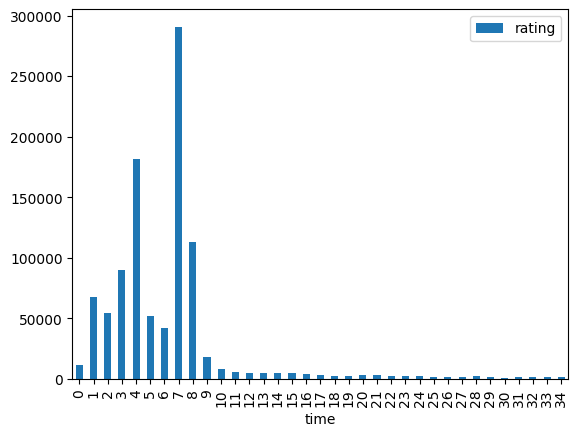

In [ ]:
from sigllm.datasets import build_ml1m

train_df, valid_df, test_df, users_map, items_map = build_ml1m(
    raw_dir="/content/SigLLM/data/raw/ml-1m/",
    out_dir="/content/SigLLM/data/processed/ml-1m",
)

print(f"✓ Train: {len(train_df):,} rows")
print(f"✓ Valid: {len(valid_df):,} rows")
print(f"✓ Test: {len(test_df):,} rows")

In [ ]:
import pandas as pd

path = "/content/SigLLM/data/processed/ml-1m/"
files = ["users_map.pkl", "items_map.pkl", "train_ood2.pkl"]

for f in files:
    data = pd.read_pickle(path + f)
    print(f"\nFile: {f}")
    print(dict(list(data.items())[:5]) if isinstance(data, dict) else data[:5])


File: users_map.pkl
{np.int64(19): np.int64(1), np.int64(20): np.int64(2), np.int64(23): np.int64(3), np.int64(36): np.int64(4), np.int64(44): np.int64(5)}

File: items_map.pkl
{np.int64(318): np.int64(1), np.int64(1234): np.int64(2), np.int64(1694): np.int64(3), np.int64(1468): np.int64(4), np.int64(3717): np.int64(5)}

File: train_ood2.pkl
   uid  iid  label   timestamp     his                             his_title  \
0    1    1      1   994556598     [0]                                    []   
1    1    2      1   994556636  [0, 1]  [, Shawshank Redemption, The (1994)]   
2    2    3      0  1009669071     [0]                                    []   
3    2    4      0  1009669071     [0]                                    []   
4    2    5      0  1009669071     [0]                                    []   

                              title  flag  not_cold  
0  Shawshank Redemption, The (1994)  -1.0         1  
1                 Sting, The (1973)  -1.0         1  
2           

## Evaluation-specific tagging: segments the test set into "Warm" (high frequency) and "Strict-Cold" (unseen) groups.

In [54]:
!source /usr/local/etc/profile.d/conda.sh && conda activate sigllm && \
python /content/SigLLM/src/sigllm/datasets/preprocess_test_cold_warm.py

02:44:16 | [1/5] Load datasets | dir=/content/SigLLM/data/processed/ml-1m/
02:44:16 | Loaded shapes | train=(33891, 9), test=(7331, 9)
02:44:16 | [2/5] Analyze User Interactions | Threshold > 3
02:44:16 | User stats | Total=740, Warm=635
02:44:16 | [3/5] Analyze Item Interactions | Threshold > 3
02:44:16 | Item stats | Total=3087, Warm=2058
02:44:16 | [4/5] Compute Warm/Cold Flags for Test Set
02:44:16 | Flag distribution | Warm=48.0%, Cold=0.4%
02:44:16 | Test DataFrame Stats | 
          not_cold  ...         cold
count  7331.000000  ...  7331.000000
mean      0.566498  ...     0.003547
std       0.495592  ...     0.059452
min       0.000000  ...     0.000000
25%       0.000000  ...     0.000000
50%       1.000000  ...     0.000000
75%       1.000000  ...     0.000000
max       1.000000  ...     1.000000

[8 rows x 3 columns]
02:44:16 | [5/5] Save Result | path=/content/SigLLM/data/processed/ml-1m/test_warm_cold_ood2.pkl


### **Note:** The following cells are **JUST ONLY USE** for visualizing and exploring the prepared data.

In [ ]:
from sigllm.datasets import process_warm_cold

process_warm_cold()

[02/19/26 15:43:50] INFO     [1/5] Load datasets |                                  preprocess_test_cold_warm.py:16
                             dir=/content/SigLLM/data/processed/ml-1m/                                             

                    INFO     Loaded shapes | train=(33891, 9), test=(7331, 9)       preprocess_test_cold_warm.py:16

                    INFO     [2/5] Analyze User Interactions | Threshold > 3        preprocess_test_cold_warm.py:16

                    INFO     User stats | Total=740, Warm=635                       preprocess_test_cold_warm.py:16

                    INFO     [3/5] Analyze Item Interactions | Threshold > 3        preprocess_test_cold_warm.py:16

...

                    INFO     [4/5] Compute Warm/Cold Flags for Test Set             preprocess_test_cold_warm.py:16

                    INFO     Flag distribution | Warm=48.0%, Cold=0.4%              preprocess_test_cold_warm.py:16

                    INFO     Test DataFrame Stats |                                 preprocess_test_cold_warm.py:16
                                       not_cold         warm         cold                                          
                             count  7331.000000  7331.000000  7331.000000                                          
                             mean      0.566498     0.480426     0.003547                                          
                             std       0.495592     0.499651     0.059452                                          
                             min       0.000000     0.000000     0.000000                                          
                             25%       0.000000     0.000000     0.000000                                          
                             50%       1.000000     0.000000     0.000000                                          
                             75%       1.000000     1.000000     0.000000                                          
                             max       1.000000     1.000000     1.000000                                          

                    INFO     [5/5] Save Result |                                    preprocess_test_cold_warm.py:16
                             path=/content/SigLLM/data/processed/ml-1m/test_warm_co                                
                             ld_ood2.pkl                                                                           

,uid,iid,label,timestamp,his,his_title,title,flag,not_cold,warm,cold
97,4,96,1,1040544350,"[0, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49...","[, Star Wars: Episode IV - A New Hope (1977), ...",Indecent Proposal (1993),1.0,1,1,0
98,4,97,1,1040544350,"[0, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49...","[, Star Wars: Episode IV - A New Hope (1977), ...",Deconstructing Harry (1997),1.0,1,1,0
99,4,98,0,1040544494,"[0, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49...","[, Star Wars: Episode IV - A New Hope (1977), ...",Big Daddy (1999),1.0,1,1,0
100,4,99,1,1040544521,"[0, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49...","[, Star Wars: Episode IV - A New Hope (1977), ...",But I'm a Cheerleader (1999),1.0,1,1,0
101,4,100,1,1040544564,"[0, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49...","[, Star Wars: Episode IV - A New Hope (1977), ...",Desperately Seeking Susan (1985),1.0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
50993,827,1013,1,1043068730,"[0, 182, 2678, 2393, 2889, 16, 789, 606, 871, ...","[, Erin Brockovich (2000), Black and White (19...","Lost Weekend, The (1945)",1.0,1,1,0
51048,829,2516,0,1033358097,"[0, 728, 1493, 357, 1196, 824, 437, 2069, 22, ...","[, Pi (1998), Shallow Grave (1994), Boys Don't...","House of the Spirits, The (1993)",1.0,1,1,0
51284,833,685,0,1031058746,"[0, 109, 675, 1167, 997, 671, 928, 222, 757, 9...","[, What Lies Beneath (2000), Replacements, The...",First Knight (1995),1.0,1,0,0
51285,833,764,1,1033997079,"[0, 109, 675, 1167, 997, 671, 928, 222, 757, 9...","[, What Lies Beneath (2000), Replacements, The...",While You Were Sleeping (1995),1.0,1,0,0


# **2. Training Stages (3 steps)**

## Step 1 — Train MF (Collaborative Filtering backbone)
- Train MF to produce user/item embeddings `e_u`, `e_i` as the recommendation signal, then freeze MF for later steps.


In [58]:
# !source /usr/local/etc/profile.d/conda.sh && conda activate sigllm && \
# pip install -U "numpy==1.26.4"

In [59]:
# !source /usr/local/etc/profile.d/conda.sh && conda activate sigllm && \
# python /content/SigLLM/numpyVer.py

In [57]:
!source /usr/local/etc/profile.d/conda.sh && conda activate sigllm && \
python /content/SigLLM/src/sigllm/pipelines/rec/train_rec_baseline.py

03:24:05 | User num: | 839
03:24:05 | Item num: | 3256
03:24:05 | warm data size: | 3522
03:24:07 | Users with only one interaction | 30
03:24:07 | Users with only one class | 44
03:24:07 | Computed user AUC count | 282
03:24:07 | Average User AUC | 0.523856
03:24:07 | Time taken to calculate user AUC | 0.36 seconds
03:24:07 | Users with only one interaction | 32
03:24:07 | Users with only one class | 55
03:24:07 | Computed user AUC count | 151
03:24:07 | Average User AUC | 0.496512
03:24:07 | Time taken to calculate user AUC | 0.19 seconds
03:24:07 | Epoch 0: Valid AUC: 0.5086, Valid uAUC: 0.5239, Test AUC: 0.4943, Test uAUC: 0.4965, Acc: 0.5062
03:24:07 | New best model found at epoch 0 with Valid uAUC: 0.5239
03:24:07 | Model saved to /content/SigLLM/mf/mf_model.pth
03:24:07 | Users with only one interaction | 30
03:24:07 | Users with only one class | 44
03:24:07 | Computed user AUC count | 282
03:24:07 | Average User AUC | 0.523973
03:24:07 | Time taken to calculate user AUC | 0.36

## Prompt Module Structure

### Subtask:
Create high-level documentation and code skeletons for `PromptTemplate` and `PromptBuilder`.


**Reasoning**:
Define the skeleton classes PromptTemplate and PromptBuilder with docstrings and pass statements as requested to structure the prompt module.



In [ ]:
class PromptTemplate:
    """
    A class to handle prompt templates with string substitution.

    Attributes:
        template (str): The template string with placeholders.
    """
    def __init__(self, template: str):
        """
        Initializes the PromptTemplate with a template string.

        Args:
            template (str): The template string containing placeholders (e.g., 'User {user_id} bought {item_id}').
        """
        # Store the template string
        pass

    def format(self, **kwargs) -> str:
        """
        Formats the template with the provided input variables.

        Args:
            **kwargs: Key-value pairs matching the placeholders in the template.

        Returns:
            str: The formatted string.
        """
        # Perform string substitution
        pass


class PromptBuilder:
    """
    A class to orchestrate the construction of prompts from raw data using PromptTemplates.

    Attributes:
        template (PromptTemplate): The template object used to generate the final prompt.
    """
    def __init__(self, template_str: str):
        """
        Initializes the PromptBuilder.

        Args:
            template_str (str): The template string to initialize the internal PromptTemplate.
        """
        # Initialize PromptTemplate
        pass

    def build_prompt(self, data: dict) -> str:
        """
        Constructs a prompt based on the input data.

        Args:
            data (dict): A dictionary containing data (e.g., user IDs, item IDs) to fill the template.

        Returns:
            str: The constructed prompt text.
        """
        # Extract necessary fields from data and use the template to format
        pass

## Rec Encoder Structure

### Subtask:
Create high-level documentation and code skeletons (comments only) for `RecEncoderBase` and the baseline `MFEncoder`.


**Reasoning**:
Define the code skeletons for RecEncoderBase and MFEncoder as requested, including the necessary imports and docstrings explaining the intended functionality.



In [ ]:
import torch
import torch.nn as nn

class RecEncoderBase(nn.Module):
    """
    Base class for Recommendation Encoders.
    """
    def __init__(self):
        """
        Initializes the encoder configuration.
        """
        super().__init__()
        # Initialize configuration logic would go here
        pass

    def forward(self, inputs):
        """
        Transforms input IDs into representations.

        Args:
            inputs: Input data (e.g., user/item IDs).

        Returns:
            Representations or model outputs.
        """
        # Logic to transform inputs to representations
        pass

class MFEncoder(RecEncoderBase):
    """
    Matrix Factorization Encoder that uses embeddings for users and items.
    """
    def __init__(self, num_users: int, num_items: int, embedding_dim: int):
        """
        Initializes the Matrix Factorization Encoder.

        Args:
            num_users (int): Number of unique users.
            num_items (int): Number of unique items.
            embedding_dim (int): Size of the embedding vectors.
        """
        super().__init__()
        # Initialize user embedding layer (nn.Embedding)
        # Initialize item embedding layer (nn.Embedding)
        pass

    def forward(self, user_ids, item_ids):
        """
        Retrieves embeddings for given user and item IDs.

        Args:
            user_ids (torch.Tensor): Tensor of user indices.
            item_ids (torch.Tensor): Tensor of item indices.

        Returns:
            dict: A dictionary containing 'user_embeds' and 'item_embeds'.
        """
        # Retrieve user embeddings using user_ids
        # Retrieve item embeddings using item_ids
        # Return embeddings
        pass

## CIE Projection Structure

### Subtask:
Create high-level documentation and code skeletons (comments only) for the `CollaborativeToLLMProjection` layer.


**Reasoning**:
Define the code skeleton for the CollaborativeToLLMProjection class with docstrings and comments as requested.



In [ ]:
import torch.nn as nn

class CollaborativeToLLMProjection(nn.Module):
    """
    Projects collaborative filtering embeddings into the LLM's token space.
    """
    def __init__(self, rec_embed_dim: int, llm_embed_dim: int):
        """
        Initializes the projection layer.

        Args:
            rec_embed_dim (int): Dimensionality of the recommendation embeddings.
            llm_embed_dim (int): Dimensionality of the LLM embeddings.
        """
        super().__init__()
        # Initialize the projection layer (e.g., a Linear layer or an MLP)
        pass

    def forward(self, rec_embeds):
        """
        Projects the recommendation embeddings.

        Args:
            rec_embeds: Input recommendation embeddings.

        Returns:
            Projected embeddings suitable for the LLM.
        """
        # Pass the input embeddings through the projection layer
        pass

## LLM Backbone Structure

### Subtask:
Create high-level documentation and code skeletons (comments only) for the `LLMBackbone` wrapper.


**Reasoning**:
Define the code skeleton for LLMBackbone class with docstrings and comments as requested.



In [ ]:
import torch.nn as nn
from transformers import AutoModelForCausalLM, AutoTokenizer

class LLMBackbone(nn.Module):
    """
    Wrapper for a pre-trained LLM.
    Handles loading the base model, tokenizer, and optional LoRA adapters.
    """
    def __init__(self, model_path: str, lora_config=None):
        """
        Initializes the LLM backbone.

        Args:
            model_path (str): Path or identifier for the pre-trained model.
            lora_config (PeftConfig, optional): Configuration for LoRA adapters.
        """
        super().__init__()
        # Load the tokenizer from the model_path
        # Load the base causal language model from model_path
        # If lora_config is provided, apply the LoRA configuration to the model using peft
        pass

    def forward(self, inputs_embeds, attention_mask=None, labels=None):
        """
        Forward pass through the LLM.

        Args:
            inputs_embeds: Embedding vectors for the input sequence.
            attention_mask: Mask to avoid attending to padding tokens.
            labels: Labels for computing the language modeling loss.

        Returns:
            Model outputs (e.g., CausalLMOutputWithPast containing loss and logits).
        """
        # Pass inputs_embeds, attention_mask, and labels to the underlying LLM model
        # Return the model outputs
        pass

## Integrated Model Skeleton

### Subtask:
Create high-level documentation and code skeletons (comments only) for the `RecLLM` integrated model and the main execution flow.


**Reasoning**:
Define the RecLLM class structure and the main execution logic skeleton with comments and placeholders to guide the integration of the recommendation encoder and the LLM backbone.



In [ ]:
import torch
import torch.nn as nn

class RecLLM(nn.Module):
    """
    Integrated model combining a Recommendation Encoder, a Projection Layer, and an LLM Backbone.
    """
    def __init__(self, rec_encoder, projection_layer, llm_backbone):
        """
        Initializes the RecLLM model with its sub-components.

        Args:
            rec_encoder (RecEncoderBase): The recommendation encoder (e.g., MFEncoder).
            projection_layer (CollaborativeToLLMProjection): Layer to project rec embeddings to LLM space.
            llm_backbone (LLMBackbone): The pre-trained LLM wrapper.
        """
        super().__init__()
        # Assign the recommendation encoder
        # Assign the projection layer
        # Assign the LLM backbone
        pass

    def forward(self, user_ids, item_ids, input_ids, attention_mask, labels=None):
        """
        Forward pass for the integrated model.

        Args:
            user_ids: Tensor of user IDs.
            item_ids: Tensor of item IDs.
            input_ids: Tokenized input text IDs for the LLM.
            attention_mask: Attention mask for the LLM.
            labels: Optional labels for training.

        Returns:
            Model outputs from the LLM.
        """
        # 1. Get recommendation embeddings from rec_encoder using user_ids and item_ids
        # 2. Project these embeddings using projection_layer to match LLM dimension
        # 3. Embed the text input_ids using the LLM's own embedding layer (from llm_backbone)
        # 4. Concatenate projected recommendation embeddings with text embeddings (soft prompting)
        # 5. Pass the combined embeddings through the llm_backbone with attention_mask and labels
        # 6. Return the model output
        pass

if __name__ == "__main__":
    # Main execution flow skeleton

    # 1. Define configuration parameters (e.g., dimensions, paths)

    # 2. Instantiate the MFEncoder

    # 3. Instantiate the CollaborativeToLLMProjection

    # 4. Instantiate the LLMBackbone (loading tokenizer and model)

    # 5. Instantiate the RecLLM model using the created components

    # 6. Create dummy input data (user_ids, item_ids, input_ids, attention_mask)

    # 7. Perform a forward pass with the dummy data
    # output = model(user_ids, item_ids, input_ids, attention_mask)

    # 8. Print the result or output shape
    pass

## Summary:

### Data Analysis Key Findings

*   **Modular Architecture Design**: Successfully outlined a modular system for a Recommendation-LLM (RecLLM) framework, separating concerns into prompting, encoding, projection, and the LLM backbone.
*   **Prompt Management**: Defined `PromptTemplate` and `PromptBuilder` classes to handle template string substitution and orchestrate the injection of data (e.g., user/item IDs) into prompts.
*   **Recommendation Encoding**: Established `RecEncoderBase` and a specific `MFEncoder` (Matrix Factorization) to transform user and item IDs into learnable embedding vectors.
*   **Dimension Alignment**: Designed the `CollaborativeToLLMProjection` layer to map lower-dimensional recommendation embeddings into the high-dimensional token space of the LLM.
*   **LLM Integration**: Structured the `LLMBackbone` class to wrap pre-trained causal language models and tokenizers, with provisions for LoRA (Low-Rank Adaptation) configuration.
*   **Soft Prompting Workflow**: The final `RecLLM` class combines these components, utilizing a workflow where projected recommendation embeddings are concatenated with text embeddings, effectively using collaborative filtering signals as soft prompts for the LLM.

### Insights or Next Steps

*   **Implementation Logic**: The current codebase consists of high-level skeletons with comments. The immediate next step is to replace the `pass` statements with actual PyTorch logic, specifically regarding embedding lookups and tensor concatenation.
*   **Training Pipeline**: The `forward` methods include arguments for `labels`, suggesting the system is designed for supervised fine-tuning. A training loop needs to be constructed to optimize the projection layer and encoder based on language modeling loss.


# Others

In [ ]:
!cd /content && wget -q --show-progress https://files.grouplens.org/datasets/movielens/ml-20m.zip
!cd /content && unzip -q ml-20m.zip
!ls -la /content/ml-20m | head

ml-20m.zip.1        100%[===================>] 189.50M  27.4MB/s    in 7.2s    
replace ml-20m/genome-scores.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-20m/genome-tags.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-20m/links.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-20m/movies.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-20m/ratings.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
y
replace ml-20m/README.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: replace ml-20m/tags.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
total 855096
drwxr-xr-x 2 root root      4096 Feb 19 09:03 .
drwxr-xr-x 1 root root      4096 Feb 19 09:02 ..
-rw-r--r-- 1 root root 323544381 Oct 17  2016 genome-scores.csv
-rw-r--r-- 1 root root     18103 Oct 17  2016 genome-tags.csv
-rw-r--r-- 1 root root    570090 Oct 17  2016 links.csv
-rw-r--r-- 1 root root   1397542 Mar 31  2015 movies.csv
-rw-r--r-- 1 root root 533444411 Mar 31  2015 ratings.csv
-rw-r--r-- 1 root root     10261 O

In [ ]:
import pandas as pd

# Đường dẫn ví dụ: /content/ml-20m/
ROOT = "/content/ml-20m"

movies = pd.read_csv(f"{ROOT}/movies.csv")          # movieId,title,genres
tags = pd.read_csv(f"{ROOT}/tags.csv")              # userId,movieId,tag,timestamp
g_tags = pd.read_csv(f"{ROOT}/genome-tags.csv")     # tagId,tag
g_scores = pd.read_csv(f"{ROOT}/genome-scores.csv") # movieId,tagId,relevance

movie_id = 1  # đổi ID bạn muốn xem

m = movies[movies.movieId == movie_id].iloc[0]
title = m["title"]
# year: lấy 4 số trong ngoặc nếu có
import re
mm = re.search(r"\((\d{4})\)", title)
year = mm.group(1) if mm else "NA"
genres = m["genres"].replace("|", ", ")

top_user_tags = (tags[tags.movieId == movie_id]["tag"]
                 .value_counts()
                 .head(15)
                 .index
                 .tolist())

top_genome = (g_scores[g_scores.movieId == movie_id]
              .merge(g_tags, on="tagId", how="left")
              .sort_values("relevance", ascending=False)
              .head(25))

top_genome_tags_25 = [f'{row["tag"]}({row["relevance"]:.2f})' for _, row in top_genome.iterrows()]

text = (
f"Movie: {title} ({year}).\n"
f"Genres: {genres}.\n"
f"User tags: {', '.join(top_user_tags) if top_user_tags else 'NA'}.\n"
f"Key attributes (genome): {', '.join(top_genome_tags_25)}."
)

print(text)

Movie: Toy Story (1995) (1995).
Genres: Adventure, Animation, Children, Comedy, Fantasy.
User tags: Pixar, animation, Disney, Tom Hanks, computer animation, children, funny, witty, toys, comedy, family, pixar, time travel, humorous, animated.
Key attributes (genome): toys(1.00), computer animation(1.00), pixar animation(1.00), kids and family(0.99), animation(0.99), kids(0.98), pixar(0.97), children(0.96), cartoon(0.96), imdb top 250(0.94), animated(0.93), childhood(0.93), great movie(0.92), disney animated feature(0.91), friendship(0.91), story(0.91), light(0.90), adventure(0.89), original(0.88), fun(0.88), disney(0.87), family(0.85), unlikely friendships(0.84), good(0.84), great(0.84).


In [ ]:
!cd /content && wget -q --show-progress https://files.grouplens.org/datasets/movielens/ml-1m.zip
!cd /content && unzip -q ml-1m.zip
!ls -la /content/ml-1m | head

ml-1m.zip.1         100%[===================>]   5.64M  10.7MB/s    in 0.5s    
replace ml-1m/movies.dat? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-1m/ratings.dat? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-1m/README? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-1m/users.dat? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
total 24336
drwxr-x--- 2 root root     4096 Feb 19 09:06 .
drwxr-xr-x 1 root root     4096 Feb 19 09:06 ..
-rw-r----- 1 root root   171308 Mar 26  2003 movies.dat
-rw-r----- 1 root root 24594131 Feb 28  2003 ratings.dat
-rw-r----- 1 root root     5577 Jan 29  2016 README
-rw-r----- 1 root root   134368 Feb 28  2003 users.dat


In [ ]:
import pandas as pd
import re

ROOT = "/content/ml-1m"

# ML-1M dùng delimiter '::' và encoding latin-1
movies = pd.read_csv(
    f"{ROOT}/movies.dat",
    sep="::",
    engine="python",
    header=None,
    names=["movieId", "title", "genres"],
    encoding="latin-1",
)

ratings = pd.read_csv(
    f"{ROOT}/ratings.dat",
    sep="::",
    engine="python",
    header=None,
    names=["userId", "movieId", "rating", "timestamp"],
    encoding="latin-1",
)

users = pd.read_csv(
    f"{ROOT}/users.dat",
    sep="::",
    engine="python",
    header=None,
    names=["userId", "gender", "age", "occupation", "zip"],
    encoding="latin-1",
)

# Mapping tuổi và nghề (theo chuẩn ML-1M docs)
AGE_MAP = {
    1: "Under 18",
    18: "18-24",
    25: "25-34",
    35: "35-44",
    45: "45-49",
    50: "50-55",
    56: "56+",
}

OCC_MAP = {
    0: "other/not specified",
    1: "academic/educator",
    2: "artist",
    3: "clerical/admin",
    4: "college/grad student",
    5: "customer service",
    6: "doctor/health care",
    7: "executive/managerial",
    8: "farmer",
    9: "homemaker",
    10: "K-12 student",
    11: "lawyer",
    12: "programmer",
    13: "retired",
    14: "sales/marketing",
    15: "scientist",
    16: "self-employed",
    17: "technician/engineer",
    18: "tradesman/craftsman",
    19: "unemployed",
    20: "writer",
}

def make_movie_card(movie_id: int, like_threshold: float = 4.0, top_k: int = 10) -> str:
    m = movies[movies.movieId == movie_id]
    if m.empty:
        return f"Không tìm thấy movieId={movie_id}"
    m = m.iloc[0]

    title = m["title"]
    mm = re.search(r"\((\d{4})\)", title)
    year = mm.group(1) if mm else "NA"
    genres = str(m["genres"]).replace("|", ", ")

    r = ratings[ratings.movieId == movie_id]
    if r.empty:
        return (
            f"Movie: {title} ({year}).\n"
            f"Genres: {genres}.\n"
            f"Ratings: NA (no ratings in dataset)."
        )

    # Stats
    cnt = int(r.shape[0])
    avg = float(r["rating"].mean())
    like_cnt = int((r["rating"] >= like_threshold).sum())
    dislike_cnt = int((r["rating"] <= 2.0).sum())

    # Join user demographics
    ru = r.merge(users, on="userId", how="left").copy()
    ru["age_group"] = ru["age"].map(AGE_MAP).fillna(ru["age"].astype(str))
    ru["occupation_name"] = ru["occupation"].map(OCC_MAP).fillna(ru["occupation"].astype(str))

    # Profile for "likes" group
    likes = ru[ru["rating"] >= like_threshold]
    if likes.empty:
        top_gender = top_age = top_occ = "NA"
    else:
        top_gender = likes["gender"].value_counts().head(2)
        top_age = likes["age_group"].value_counts().head(3)
        top_occ = likes["occupation_name"].value_counts().head(3)

        top_gender = ", ".join([f"{k}({v})" for k, v in top_gender.items()])
        top_age = ", ".join([f"{k}({v})" for k, v in top_age.items()])
        top_occ = ", ".join([f"{k}({v})" for k, v in top_occ.items()])

    # Recentness (optional)
    # Convert unix timestamp to year for a rough view
    ru["year"] = pd.to_datetime(ru["timestamp"], unit="s").dt.year
    top_years = ru["year"].value_counts().head(3)
    top_years = ", ".join([f"{k}({v})" for k, v in top_years.items()])

    card = (
        f"Movie: {title} ({year}).\n"
        f"Genres: {genres}.\n"
        f"Ratings: count={cnt}, avg={avg:.2f}, likes(>={like_threshold})={like_cnt}, low(<=2)={dislike_cnt}.\n"
        f"Audience (likes group): gender={top_gender}; age={top_age}; occupation={top_occ}.\n"
        f"Rating years (top): {top_years}."
    )
    return card

# Ví dụ: Toy Story trong ML-1M thường movieId=1
print(make_movie_card(movie_id=1))

Movie: Toy Story (1995) (1995).
Genres: Animation, Children's, Comedy.
Ratings: count=2077, avg=4.15, likes(>=4.0)=1655, low(<=2)=77.
Audience (likes group): gender=M(1178), F(477); age=25-34(656), 35-44(357), 18-24(336); occupation=college/grad student(228), other/not specified(223), executive/managerial(164).
Rating years (top): 2000(1967), 2001(91), 2002(17).
